# 类激活映射
**类激活映射（Class Activation Mapping，CAM）** 是一种可视化技术，旨在揭示深度神经网络在进行图像分类时，最关注的图像区域。通过生成CAM，我们可以更好地理解卷积神经网络（CNN）在做出分类决策时，哪些部分的图像对最终的分类结果起到了关键作用。

### 1. **背景：为什么需要CAM？**

在深度学习中，尤其是在使用卷积神经网络（CNN）进行图像分类时，模型通常会通过多层的卷积操作提取图像中的特征，并最终做出分类决策。然而，CNN内部的决策过程通常是不透明的，这使得它们被视为“黑箱模型”。我们通常无法直接了解模型是如何看待输入图像的，也不清楚模型是依赖图像的哪些部分进行分类的。

**CAM的出现**正是为了解决这个问题，它提供了一种有效的方式，帮助我们通过可视化模型的“注意力”区域来解释网络的决策。

### 2. **CAM的工作原理**

类激活映射通过结合特征图和梯度来生成可视化图像，下面是CAM的工作原理步骤：

#### (1) **前向传播**

首先，输入图像通过网络的多个卷积层和全连接层进行前向传播。最后的输出层是模型的预测结果，它表示每个类别的得分（例如，对于二分类任务，输出层会有两个值，表示属于两个类别的概率）。

#### (2) **反向传播**

在进行反向传播时，计算每一层的梯度。具体来说，反向传播将损失函数对每个类别的梯度传递回去，告诉我们哪些特征对分类决策起到了重要作用。

#### (3) **计算类激活映射**

类激活映射通过将每个卷积层输出的特征图（feature map）与反向传播得到的梯度进行加权求和。这个过程的核心思想是：通过特征图中的每个位置的梯度信息，计算该位置对最终分类结果的影响。然后将每个位置的加权特征图进行求和，最终生成一个类激活映射图。

公式可以表示为：

$$
\text{CAM} = \sum_{i} \text{Grad}_{i} \cdot \text{FeatureMap}_{i}
$$

其中：

* $\text{Grad}_{i}$ 是第 $i$ 个特征图的梯度。
* $\text{FeatureMap}_{i}$ 是第 $i$ 个特征图。
* 加权求和的过程得到每个位置的值，代表该区域对分类结果的贡献。

#### (4) **生成热力图**

通过将计算出的类激活映射映射到输入图像的空间上，可以生成一个热力图。这个热力图显示了图像中每个区域对最终分类结果的影响程度，通常，越热（颜色越深）的区域表示对分类结果的贡献越大。

### 3. **CAM的优势**

* **可解释性**：CAM提供了一种直观的方式，帮助我们理解CNN如何做出分类决策。它能够告诉我们模型最关注图像中的哪些区域，从而提高模型的可解释性。
* **模型诊断**：如果模型的注意力区域不符合人类的预期（例如，模型错误地关注了图像中的不相关部分），那么我们可以通过CAM诊断出模型的潜在问题，并进一步改进模型。

### 4. **CAM的局限性**

* **仅限于卷积层输出**：标准的CAM方法只能用于那些在网络中包含全局平均池化（Global Average Pooling，GAP）和全连接层之前的卷积层。因此，不能直接应用于所有类型的网络架构，特别是那些没有GAP层的网络。
* **局部信息限制**：传统的CAM方法通过将梯度与特征图相乘生成一个热力图，这对于某些情况（如小物体的检测）可能不够准确，因为它依赖于整个区域的加权信息。

### 5. **如何改进CAM**

为了解决标准CAM的一些局限性，出现了改进版本，如**Grad-CAM**（Gradient-weighted Class Activation Mapping）。Grad-CAM不仅可以用于包含全局平均池化层的网络，还能通过计算每个卷积层的梯度来生成更加细致的类激活映射。

#### Grad-CAM的工作流程

* 在计算类激活映射时，Grad-CAM考虑了网络中每个卷积层的梯度信息，从而生成更加精确的激活图。
* Grad-CAM的优点在于，它可以被应用到更多不同类型的网络架构中，包括那些没有全局平均池化层的模型。

### 6. **应用示例**

假设我们有一个用于猫狗分类的模型，输入一张图片，模型输出一个猫或狗的预测标签。通过CAM，我们可以可视化模型认为图像中的哪些区域代表猫或狗。例如，如果模型在预测“猫”时，CAM可能会显示图像中猫的头部或耳朵区域为高亮区域，表明这些区域对分类决策最为重要。

### 7. **总结**

类激活映射（CAM）是一个强大的工具，用于帮助理解和解释深度神经网络的决策过程。它通过结合卷积层的特征图和反向传播得到的梯度信息，生成一个可视化图像，展示网络在做出分类决策时最关注的图像区域。通过CAM，我们可以提高深度学习模型的可解释性，增强用户对模型的信任，同时还可以发现模型潜在的缺陷和不足。

---

# CAM代码

### 1. **导入必要的库和定义函数**

在代码的开头，导入了用于训练和可视化的常见库，如`torch`（深度学习框架）、`torchvision`（计算机视觉相关工具）、`matplotlib`（绘图工具）、`cv2`（图像处理工具）等。

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import transforms
from torchvision import models
from torchsummary import summary
from matplotlib import pyplot as plt
import numpy as np
import cv2
import tkinter as tk
from tkinter import filedialog

接下来，定义了两个辅助函数：`myimshows` 和 `tensor2img`。

#### `myimshows` 函数

该函数用于将多个图像以子图的形式显示，并且保存为图片。它接受以下参数：

* `imgs`：图像列表。
* `titles`：图像标题。
* `fname`：保存图像的文件名。
* `size`：每个子图的大小。

#### `tensor2img` 函数

该函数将PyTorch张量转换为图像，并根据需要应用热力图。它可以用于生成类激活映射（CAM）等热力图图像。参数如下：

* `tensor`：输入的张量数据。
* `heatmap`：是否生成热力图。
* `shape`：目标图像的尺寸。

---

In [3]:
def myimshows(imgs, titles=False, fname="test.jpg", size=6):
    lens = len(imgs)
    fig = plt.figure(figsize=(size * lens,size))
    if titles == False:
        titles="0123456789"
    for i in range(1, lens + 1):
        cols = 100 + lens * 10 + i
        plt.xticks(())
        plt.yticks(())
        plt.subplot(cols)
        if len(imgs[i - 1].shape) == 2:
            plt.imshow(imgs[i - 1], cmap='Reds')
        else:
            plt.imshow(imgs[i - 1])
        plt.title(titles[i - 1])
    plt.xticks(())
    plt.yticks(())
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
def tensor2img(tensor,heatmap=False,shape=(224,224)):
    np_arr=tensor.detach().numpy()[0]
    #对数据进行归一化
    if np_arr.max()>1 or np_arr.min()<0:
        np_arr=np_arr-np_arr.min()
        np_arr=np_arr/np_arr.max()
    np_arr=(np_arr*255).astype(np.uint8)
    if np_arr.shape[0]==1:
        np_arr=np.concatenate([np_arr,np_arr,np_arr],axis=0)
    np_arr=np_arr.transpose((1,2,0))
    if heatmap:
        np_arr = cv2.resize(np_arr, shape)
        np_arr = cv2.applyColorMap(np_arr, cv2.COLORMAP_JET)  # 将热力图应用于原始图像
    return np_arr/255
 
def backward_hook(module, grad_in, grad_out):
    grad_block.append(grad_out[0].detach())
    print("backward_hook:",grad_in[0].shape,grad_out[0].shape)
 
def farward_hook(module, input, output):
    fmap_block.append(output)
    print("farward_hook:",input[0].shape,output.shape)

### 2. **加载预训练模型和自定义修改**

```python
model = models.resnet50(pretrained=False)      # 加载ResNet50模型（未使用预训练权重）
model.fc = nn.Linear(model.fc.in_features, 2) # 修改全连接层以适应2类分类
```

* 这里使用ResNet50模型，并根据需要将其最后的全连接层修改为适应2个类别（可以根据实际任务调整）。

---

### 3. **加载训练好的模型权重**

```python
checkpoint = torch.load('best_resnet50.pth', map_location=device)
model.load_state_dict(checkpoint)
```

* 使用`torch.load`加载训练好的模型权重文件，路径是`'best_resnet50.pth'`。这个文件应该是在训练过程中保存的最佳模型权重。

---

In [9]:
# 定义设备
device = torch.device("cpu")
# 加载模型
model = models.resnet50(pretrained=False)      # 这里 pretrained=False，因为我们要加载自己训练的权重
model.fc = nn.Linear(model.fc.in_features, 2) # 类别数要和训练时一致

# 加载权重
checkpoint = torch.load('best_resnet50.pth', map_location=device)
model.load_state_dict(checkpoint)
model.eval()  # 评估模式
#summary(model,input_size=(3,512,512))

C:\Users\28497\AppData\Local\Temp\ipykernel_6020\1288153139.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('best_resnet50.pth', map_location=dev

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### 4. **注册Hook（钩子函数）**

```python
fh = model.layer4.register_forward_hook(farward_hook)
bh = model.layer4.register_backward_hook(backward_hook)
```

* 在这里，我们在ResNet50的最后一层（`layer4`）注册了前向和反向传播钩子函数（Hook）。这些钩子函数分别记录前向传播时的特征图（`fmap_block`）和反向传播时的梯度（`grad_block`）。

#### `farward_hook` 函数

* 该函数在每次前向传播时调用，保存该层输出的特征图。

#### `backward_hook` 函数

* 该函数在反向传播时调用，保存该层的梯度。

---

### 5. **加载图像并进行预测**

```python
bin_data = torchvision.io.read_file(path)
img = torchvision.io.decode_image(bin_data) / 255  # 解码图像并归一化
img = img.unsqueeze(0)  # 增加一个维度，变成BCHW格式
```

* 加载图像文件，并将其转化为PyTorch的张量，之后进行归一化处理，最后转换为BCHW格式（批大小为1，通道数为3，高度和宽度为224x224）。

```python
preds = model(img)  # 进行模型预测
```

* 使用训练好的ResNet50模型进行图像分类预测。

---

In [10]:
# 注册hook
fh=model.layer4.register_forward_hook(farward_hook)
bh=model.layer4.register_backward_hook(backward_hook)

#定义存储特征和梯度的数组
fmap_block = list()
grad_block = list()
 
# 用法示例
def select_image_file():
    root = tk.Tk()
    root.withdraw()  # 隐藏主窗口
    root.attributes('-topmost', 1)  # 设置窗口在所有窗口的最前面
    root.geometry("+0+0")  # 将窗口放置在屏幕的左上角
    file_path = filedialog.askopenfilename(
        title="选择要预测的图片",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp"), ("All files", "*.*")]
    )
    return file_path

#加载变量并进行预测
path = select_image_file()
bin_data=torchvision.io.read_file(path)#加载二进制数据
img=torchvision.io.decode_image(bin_data)/255#解码成CHW的图片
img=img.unsqueeze(0)#变成BCHW的数据，B==1; squeeze
img=torchvision.transforms.functional.resize(img,[224, 224])
preds=model(img)
print("pred type:",preds.argmax(1))

farward_hook: torch.Size([1, 1024, 14, 14]) torch.Size([1, 2048, 7, 7])
pred type: tensor([1])


d:\miniconda3\envs\torch_cu124\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


### 6. **构造标签并进行反向传播**

```python
trues = torch.ones((1,), dtype=torch.int64) * clas  # 真实标签
ce_loss = nn.CrossEntropyLoss()  # 损失函数
loss = ce_loss(preds, trues)  # 计算损失
loss.backward()  # 反向传播
```

* 构造一个真实标签`trues`（假设标签是`1`），并使用交叉熵损失函数计算损失后进行反向传播。

---

In [11]:
#构造label，并进行反向传播
clas=1#
trues=torch.ones((1,),dtype=torch.int64)*clas
ce_loss=nn.CrossEntropyLoss()
loss=ce_loss(preds,trues)
loss.backward()
 
# 卸载hook
fh.remove()
bh.remove()

backward_hook: torch.Size([1, 2048, 7, 7]) torch.Size([1, 2048, 7, 7])


### 7. **提取特征和梯度**

```python
layer1_grad = grad_block[-1]  # 获取最后一层的梯度
layer1_fmap = fmap_block[-1]  # 获取最后一层的特征图
```

* 从`grad_block`和`fmap_block`中提取反向传播后的梯度和前向传播的特征图。

---

### 8. **计算类激活映射（CAM）**

```python
cam = layer1_grad[0, 0].mul(layer1_fmap[0, 0])
for i in range(1, layer1_grad.shape[1]):
    cam += layer1_grad[0, i].mul(layer1_fmap[0, i])
```

* 通过将每个通道的梯度与特征图相乘并求和，得到类激活映射（CAM）。

---

### 9. **可视化**

```python
img_np = tensor2img(img)  # 将输入图像转换为图像格式
layer1_grad_np = tensor2img(layer1_grad, heatmap=True, shape=(224, 224))  # 生成梯度热力图
layer1_fmap_np = tensor2img(layer1_fmap, heatmap=True, shape=(224, 224))  # 生成特征图热力图
cam_np = tensor2img(cam, heatmap=True, shape=(224, 224))  # 生成类激活映射热力图
```

* 将输入图像、特征图、梯度图以及类激活映射（CAM）转化为可视化图像，并进行热力图处理。

```python
myimshows([img_np, cam_np, cam_np * 0.4 + img_np * 0.6], ['image', 'cam', 'cam + image'])
```

* 最后，将输入图像、类激活映射（CAM）以及两者结合的图像一起展示。

颜色越深（红），表示该区域的值越大


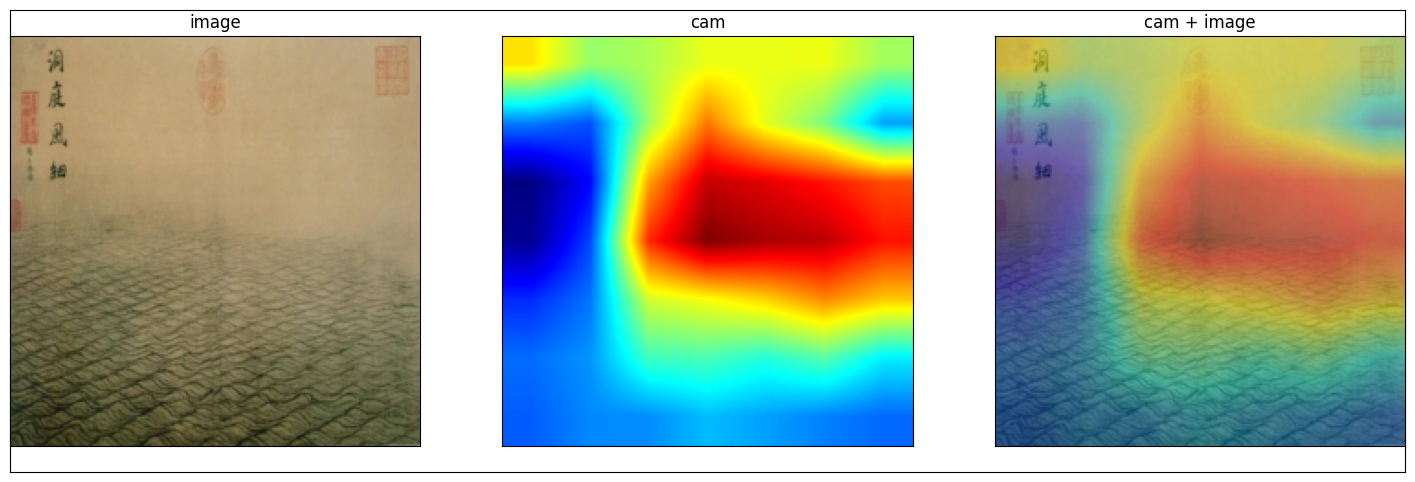

In [12]:
#取出相应的特征和梯度
layer1_grad=grad_block[-1] #layer1_grad.shape [1, 64, 128, 128]
layer1_fmap=fmap_block[-1]
 
#将梯度与fmap相乘
cam=layer1_grad[0,0].mul(layer1_fmap[0,0])
for i in range(1,layer1_grad.shape[1]):
    cam+=layer1_grad[0,i].mul(layer1_fmap[0,i])
layer1_grad=layer1_grad.sum(1,keepdim=True) #layer1_grad.shape [1, 1, 128, 128]
layer1_fmap=layer1_fmap.sum(1,keepdim=True) #为了统一在tensor2img函数中调用
cam=cam.reshape((1,1,*cam.shape))
 
#进行可视化
img_np=tensor2img(img)
#layer1_fmap=torchvision.transforms.functional.resize(layer1_fmap,[224, 224])
layer1_grad_np=tensor2img(layer1_grad,heatmap=True,shape=(224,224))
layer1_fmap_np=tensor2img(layer1_fmap,heatmap=True,shape=(224,224))
cam_np=tensor2img(cam,heatmap=True,shape=(224,224))
print("颜色越深（红），表示该区域的值越大")
myimshows([img_np,cam_np,cam_np*0.4+img_np*0.6],['image','cam','cam + image'])    